# Histogramas

## 1. ¿Qué son?

Son otra manera de visualizar la distribución de los datos. Es decir, nos permiten ver no sólo el comportamiento global (como las medidas de tendencia central o de variabilidad) sino también una "foto panorámica" de todos los datos.

## 2. Elementos de un histograma

Un histograma se obtiene:

1. Definiendo el número de intervalos (bins) en los que se dividirá la variable numérica
2. Dividiendo el rango de la variable numérica en este número de intervalos
3. Asignando cada dato en la variable a uno de los intervalos obtenidos en (2)
4. Realizando el conteo (frecuencia) del número de datos en cada intervalo
5. Generando un gráfico donde:
   - El eje horizontal contendrá cada intervalo
   - El eje vertical contendrá el conteo correspondiente a cada intervalo
   
![](elementos-histograma.png)

Por ejemplo, en la figura anterior tendremos:
1. 10 intervalos
2. Por cada intervalo tendremos el conteo del número de datos dentro de dicho *bin*
3. Y el conteo anterior se dibuja como una barra. La altura de la barra es proporcional a la frecuencia (conteo)

## 3. ¿Cuándo usar un histograma?

Cuando queremos ver la distribución de una variable numérica. Específicamente:

- Podemos ver la media y la dispersión, aunque **no de forma explícita**
- Si hay simetría o asimetría (*skewness*) en la distribución
- Dentro de qué rango de valores se encuentra la mayor parte de los datos
- Podemos hacernos a una idea del tipo de distribución (Normal/Gaussiana, uniforme, Poisson, etc.)

Algunas desventajas frente a los gráficos de caja:

- El histograma no contiene los valores de la media ni de la dispersión (se podrían superponer a la gráfica, pero por defecto no están presentes)
- No facilita ver la presencia de *outliers*

Además nos permite comparar distribuciones de variables (esto lo veremos más adelante en el análisis bivariado).


## 4. ¿Cómo generar gráficos de histogramas?

Para entender todo lo anterior podemos hacer un ejemplo práctico que nos permitirá ver cómo generar e interpretar este tipo de gráficas.

Comencemos cargando el set de datos *data-histogramas.csv* usado en la lección anterior:

In [1]:
import pandas as pd

ruta = '/Users/miguel/Library/CloudStorage/GoogleDrive-miguel@codificandobits.com/My Drive/02-CODIFICANDOBITS.COM/04-Academia/01-Cursos/21-2024-03-Estadística-Descriptiva/datos/'
df = pd.read_csv(ruta + 'data-histogramas.csv')
df

,var_1,var_2,var_3
0,0.496714,0.645917,0.125977
1,-0.138264,0.570778,0.204921
2,0.647689,0.356097,0.164068
3,1.523030,0.986515,0.127733
4,-0.234153,0.605775,0.115127
...,...,...,...
495,0.538910,0.680141,0.113182
496,-1.037246,0.618611,0.267363
497,-0.190339,0.752717,0.269974
498,-0.875618,0.158605,0.251157


Tenemos tres variables (columnas *var_1*, *var_2* y *var_3*) y un total de 500 datos (filas).

Comencemos viendo la distribución de cada variable de manera individual usando nuevamente Seaborn (lección 12 del curso "Pandas Nivel Intermedio"):

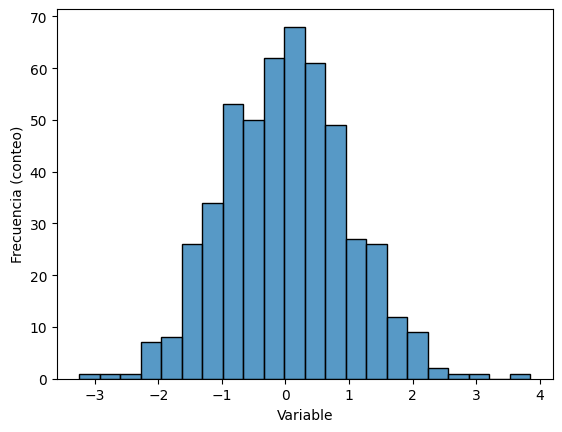

In [2]:
import seaborn as sns

# Histograma "var_1"
ax = sns.histplot(data=df['var_1'])
ax.set_xlabel('Variable')
ax.set_ylabel('Frecuencia (conteo)');

Si no definimos el número de intervalos (*bins*) este será calculado automáticamente por Seaborn (en el caso anterior este número de bins fue calculado automáticamente y es igual a 22).

Con este histograma podemos tener una idea general de la distribución de esta variable:
1. Su media es aproximadamente 0 (la barra de mayor altura)
2. Los intervalos alrededor de -3 y de 3-4 (aproximadamente) no tienen casi datos
3. La distribución es similar a una distribución normal (simétrica respecto a la media)

Vemos que el histograma nos proporciona información relevante de la distribución de los datos pero no al nivel de detalle con que lo hacen los gráficos de caja.

El uso de histogramas también nos permite ver el tipo de distribución que podrían tener los datos. Por ejemplo veamos las distribuciones de las variables 2 y 3:

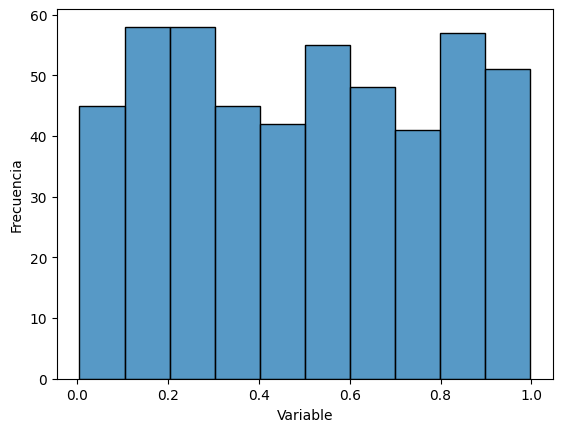

In [3]:
# Histograma "var_2"
ax = sns.histplot(data=df['var_2'])
ax.set_xlabel('Variable')
ax.set_ylabel('Frecuencia');

En este caso tenemos una distribución aproximadamente uniforme (donde todos los valores son muy similares independientemente del intervalo).

Veamos la variable 3:

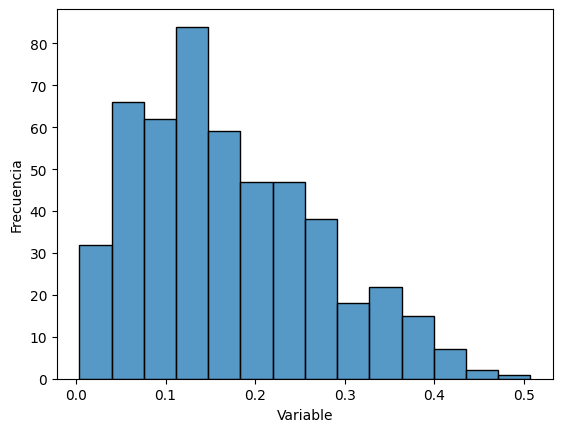

In [4]:
# Histograma "var_3"
ax = sns.histplot(data=df['var_3'])
ax.set_xlabel('Variable')
ax.set_ylabel('Frecuencia');

En este caso tenemos una distribución asimétrica, con un sesgo hacia la izquierda.

## 5. Opciones adicionales de visualización

Usando el parámetro `bins` podemos controlar el número de intervalos:

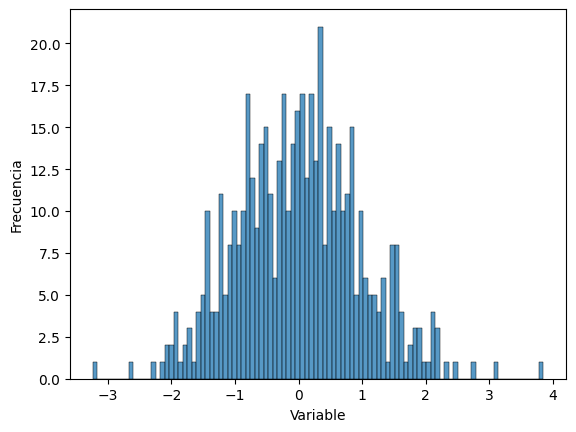

In [7]:
# Histograma "var_1" con 100 bins
ax = sns.histplot(data=df['var_1'], bins=100)
ax.set_xlabel('Variable')
ax.set_ylabel('Frecuencia');

Y como elemento adicional podemos agregar la media y la desviación estándar de los datos:

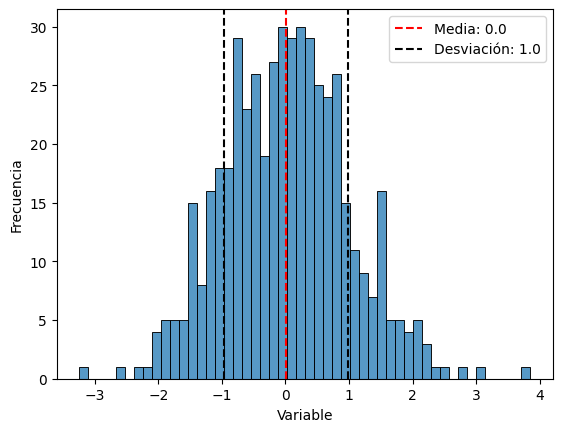

In [ ]:
# Generar histograma con 50 bins
ax = sns.histplot(data=df['var_1'], bins=50)
ax.set_xlabel('Variable')
ax.set_ylabel('Frecuencia');

# Calcular y dibujar media y desviación estándar
media, std = df['var_1'].mean(), df['var_1'].std()
#ax.axvline dibuja las lineas verticales
ax.axvline(media, color='red', linestyle='--', label=f'Media: {media:.1f}')
ax.axvline(media+std, color='black', linestyle='--', label=f'Desviación: {std:.1f}')
ax.axvline(media-std, color='black', linestyle='--')
ax.legend();

## 6. Ejemplo práctico

Volvamos al set de datos *tasas-crimenes.csv* y analicemos la distribución de las variables población y tasa de homicidios a través de los histogramas.

Comencemos leyendo el set de datos:

In [9]:
df = pd.read_csv(ruta + 'tasas-crimenes.csv')
df

,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA
5,Colorado,5029196,2.8,CO
6,Connecticut,3574097,2.4,CT
7,Delaware,897934,5.8,DE
8,Florida,18801310,5.8,FL
9,Georgia,9687653,5.7,GA


Y ahora analicemos la población añadiendo las observaciones respectivas:

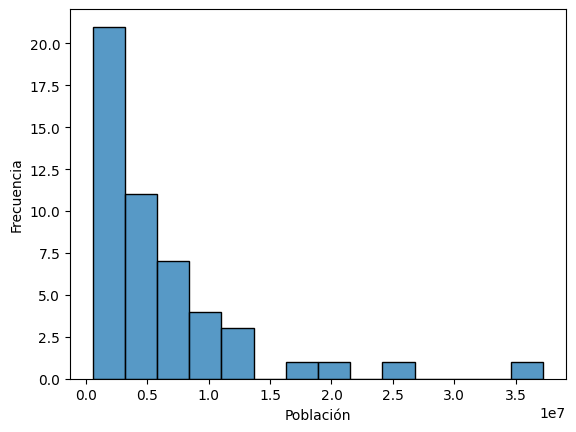

In [10]:
# Histograma "población"
ax = sns.histplot(data=df['Population'])
ax.set_xlabel('Población')
ax.set_ylabel('Frecuencia');

Observaciones:

- La distribución tiene un sesgo hacia valores "bajos" de población (entre 1 y 15 millones de habitantes)
- Existen estados con poblaciones muy altas (*outliers*) del orden de 25 y 35 millones.

Aunque en este caso es posible ver los *outliers*, no siempre resulta fácil cuando hacemos uso de histogramas.

Podemos ajustar el número de *bins* para tratar de ver mejor los detalles de estos *outliers*:

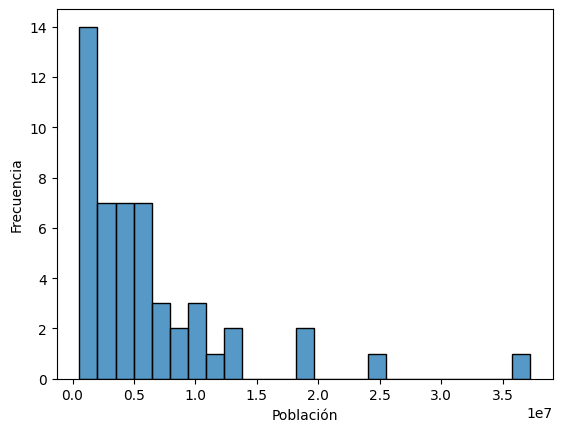

In [11]:
# Histograma "población"
ax = sns.histplot(data=df['Population'],bins=25)
ax.set_xlabel('Población')
ax.set_ylabel('Frecuencia');

Y acá podemos ver de forma detallada que en realidad hay 4 outliers:

- 2 ciudades con poblaciones cercanas a los 20 millones
- 1 ciudad con población de casi 25 millones
- 1 ciudad con población un poco mayor de 35 millones

Veamos qué ocurre con la tasa de asesinatos:

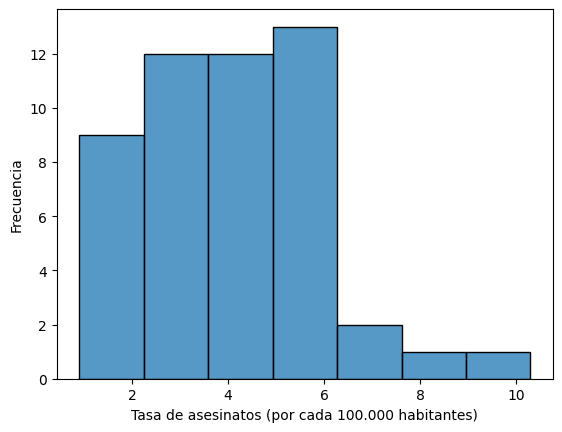

In [12]:
# Histograma "tasa de asesinatos"
ax = sns.histplot(data=df['Murder.Rate'])
ax.set_xlabel('Tasa de asesinatos (por cada 100.000 habitantes)')
ax.set_ylabel('Frecuencia');

Se aprecia un comportamiento bastante uniforme en los intervalos de 0 a 6. Esto puede estar debido no a las características de los datos sino al número de bins (calculado automáticamente como 7).

Usemos un número mayor de bins (20) para tener más granularidad en el histograma y ver algunos detalles:

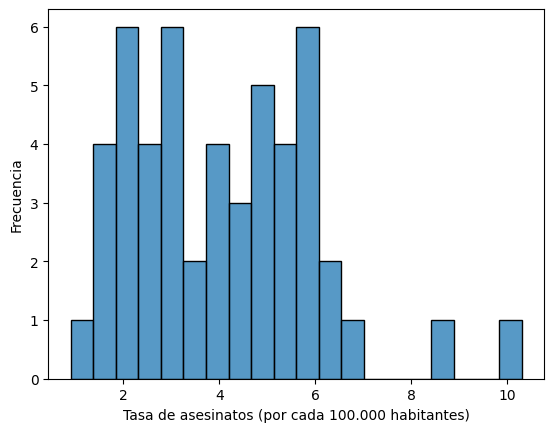

In [13]:
# Histograma "tasa de asesinatos"
ax = sns.histplot(data=df['Murder.Rate'], bins=20)
ax.set_xlabel('Tasa de asesinatos (por cada 100.000 habitantes)')
ax.set_ylabel('Frecuencia');

¡Y vemos que en realidad en el rango de 0 a 6 no tenemos una distribución de los datos completamente uniforme.

Observaciones:

- No existe como tal un valor central de tasa de asesinatos y en su lugar dichas tasas están distribuidas en el rango de 1 a 7 por cada 100.000 habitantes.
- Existen 2 estados con tasas de homicidios muy altas (de aproximadamente 9 y 10 homicidios por cada 100.000 habitantes).

## 4. Aspectos a tener en cuenta

- Los histogramas son otra manera de visualizar la distribución de nuestros datos.
- Algunas desventajas con respecto a los *boxplots*:
    - Por defecto no están incluidos la media y la desviación en la gráfica
    - Dependiendo del número de intervalos escogido se podrán ver más o menos detalles de la distribución (en algunos casos estos detalles se podrían enmascarar).